# Sci-Plex 3 EDA (24 h subset)

CellCast — milestone 2, Step B.4.

Working with the scPerturb v1.4 release of Srivatsan et al. 2020.
File: `~/data/sciplex/SrivatsanTrapnell2020_sciplex3.h5ad` (SHA256 in `data/PROVENANCE.md`).

This notebook restricts to the **24 h time point only** per the decision in `docs/DESIGN.md` §2 / `docs/DECISIONS.md` (2026-05-14). The 72 h subset is held out as a counterfactual target.

Demultiplex-failure cells (`cell_line` NaN, ~36.5k) are also dropped.

UMAP is deliberately **not** computed here — see deferral note at the end.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100

H5AD = os.path.expanduser("~/data/sciplex/SrivatsanTrapnell2020_sciplex3.h5ad")

## Load and apply the 24 h filter

In [2]:
adata = sc.read_h5ad(H5AD, backed="r")
print(f"raw shape: {adata.shape}   ({adata.n_obs:,} cells x {adata.n_vars:,} genes)")

obs = adata.obs.copy()
n_total = len(obs)

# Drop demultiplex failures (no cell_line assignment)
mask_valid = obs["cell_line"].notna()
n_demux_fail = int((~mask_valid).sum())

# Drop 72 h
mask_24h = obs["time"] == 24.0
n_72h = int((mask_valid & (obs["time"] == 72.0)).sum())

keep = mask_valid & mask_24h
obs24 = obs.loc[keep].copy()

# Cast categories to str for clean groupby
for c in ["cell_line", "perturbation", "target", "pathway",
          "pathway_level_1", "pathway_level_2", "replicate"]:
    obs24[c] = obs24[c].astype(str)
obs24["dose_value"] = obs24["dose_value"].astype(float)

print()
print(f"total cells:                  {n_total:>9,}")
print(f"  - demultiplex failures:     {n_demux_fail:>9,}  (dropped)")
print(f"  - 72h cells:                {n_72h:>9,}  (dropped per DESIGN.md §2)")
print(f"  = 24h subset (this notebook): {len(obs24):>9,}")

raw shape: (799317, 110983)   (799,317 cells x 110,983 genes)



total cells:                    799,317
  - demultiplex failures:        36,522  (dropped)
  - 72h cells:                   82,110  (dropped per DESIGN.md §2)
  = 24h subset (this notebook):   680,685


## Control label — what string does scPerturb use?

Original Sci-Plex used DMSO as vehicle. We want to confirm exactly what string appears in `perturbation` for control cells, since the MAMMAL prompt template will need a deterministic control identifier (or matched baseline expression).

In [3]:
print("unique 'perturbation' values that look like a control:")
pert_unique = sorted(obs24["perturbation"].unique())
candidates = [p for p in pert_unique if any(k in p.lower()
              for k in ["control", "vehicle", "dmso", "ctrl", "veh"])]
print(f"  matched candidates: {candidates}")

# All values containing 'c' for paranoia
print()
print(f"total unique perturbations in 24h subset: {len(pert_unique)}")
print(f"first 10 alphabetically: {pert_unique[:10]}")

# Control cells: how are they recorded across other fields?
ctrl_label = candidates[0] if candidates else None
ctrl = obs24[obs24["perturbation"] == ctrl_label]
print()
print(f"control label: {ctrl_label!r}")
print(f"control cells in 24h subset: {len(ctrl):,}")
print()
print("control cells by cell_line:")
print(ctrl.groupby("cell_line").size().to_string())
print()
print(f"control dose_value(s):   {sorted(ctrl['dose_value'].unique())}")
print(f"control target value(s): {ctrl['target'].unique().tolist()}")
print(f"control pathway(s):      {ctrl['pathway'].unique().tolist()}")

unique 'perturbation' values that look like a control:
  matched candidates: ['control']

total unique perturbations in 24h subset: 189
first 10 alphabetically: ['(+)-JQ1', '2-Methoxyestradiol (2-MeOE2)', 'A-366', 'ABT-737', 'AC480 (BMS-599626)', 'AG-14361', 'AG-490 (Tyrphostin B42)', 'AICAR (Acadesine)', 'AMG-900', 'AR-42']

control label: 'control'
control cells in 24h subset: 15,494

control cells by cell_line:
cell_line
A549    3773
K562    3935
MCF7    7786

control dose_value(s):   [0.0]
control target value(s): ['Vehicle']
control pathway(s):      ['Vehicle']


## Plot 1 — Cells per cell line

/tmp/ipykernel_208580/949795736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")


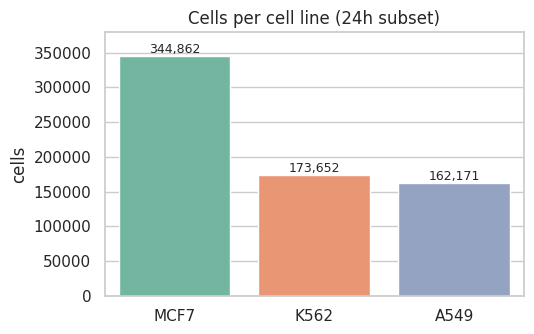

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
counts = obs24["cell_line"].value_counts().sort_values(ascending=False)
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
ax.set_ylabel("cells")
ax.set_xlabel("")
ax.set_title("Cells per cell line (24h subset)")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.10)
plt.tight_layout()
plt.show()

## Plot 2 — Top 20 drugs by cell count

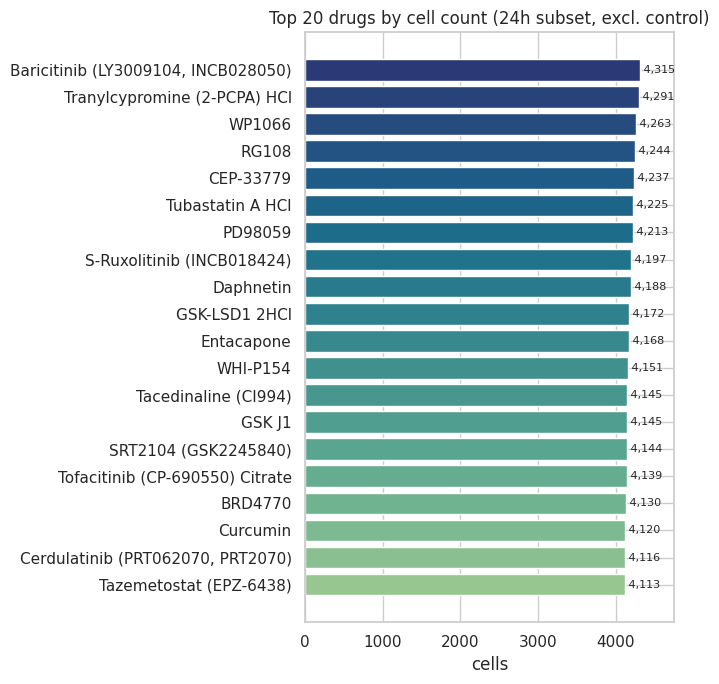

In [5]:
drugs24 = obs24[obs24["perturbation"] != "control"]
top20 = drugs24["perturbation"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(top20.index, top20.values, color=sns.color_palette("crest", 20))
ax.set_xlabel("cells")
ax.set_title("Top 20 drugs by cell count (24h subset, excl. control)")
for i, v in enumerate(top20.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
ax.set_xlim(0, top20.max() * 1.10)
plt.tight_layout()
plt.show()

## Plot 3a — Overall dose distribution (drug cells)

/tmp/ipykernel_208580/2518042328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"{int(d)} nM" for d in dose_counts.index],


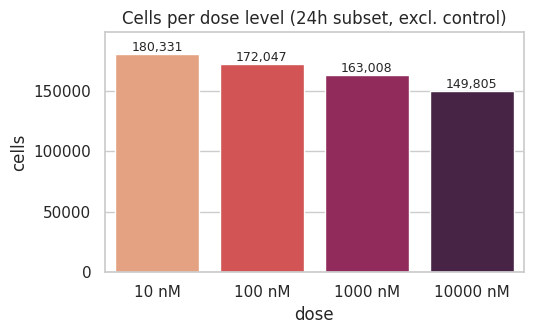

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
dose_counts = drugs24["dose_value"].value_counts().sort_index()
sns.barplot(x=[f"{int(d)} nM" for d in dose_counts.index],
            y=dose_counts.values, ax=ax, palette="rocket_r")
ax.set_ylabel("cells")
ax.set_xlabel("dose")
ax.set_title("Cells per dose level (24h subset, excl. control)")
for i, v in enumerate(dose_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, dose_counts.max() * 1.10)
plt.tight_layout()
plt.show()

## Plot 3b — Dose distribution by pathway_level_1 (faceted)

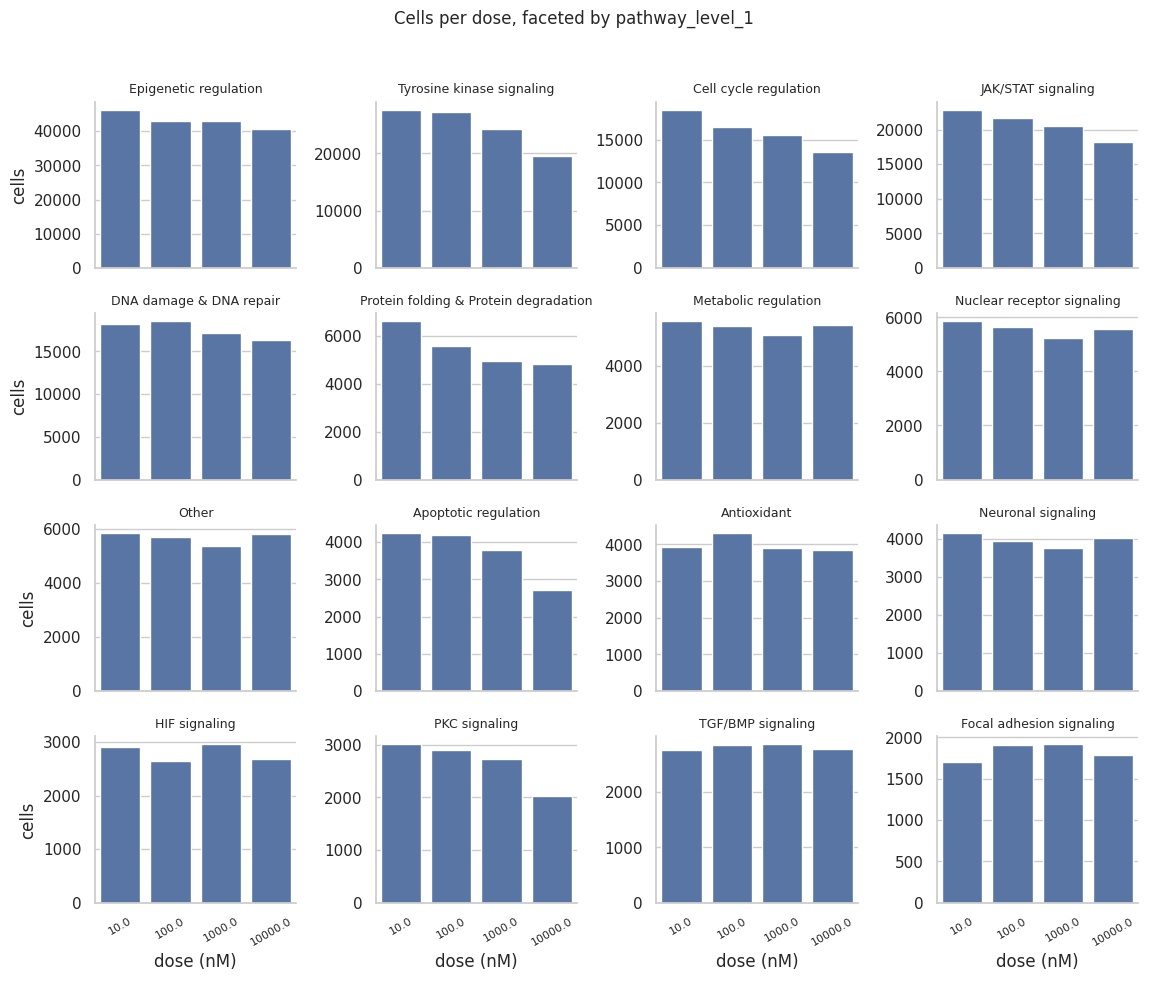

In [7]:
order_levels = (drugs24.groupby("pathway_level_1")["perturbation"]
                .nunique().sort_values(ascending=False).index.tolist())

g = sns.catplot(
    data=drugs24,
    x="dose_value",
    col="pathway_level_1",
    col_wrap=4,
    col_order=order_levels,
    kind="count",
    height=2.4, aspect=1.2,
    color="#4c72b0",
    sharey=False,
)
g.set_titles("{col_name}", size=9)
g.set_axis_labels("dose (nM)", "cells")
for ax in g.axes.flat:
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)
        lbl.set_fontsize(8)
g.fig.suptitle("Cells per dose, faceted by pathway_level_1", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Plot 4 — Cells-per-condition distribution

A condition is a `(drug, dose, cell_line)` triple. Long-tail conditions are typically cytotoxic-drug-at-high-dose combinations where cells died during the experiment — informative signal, not noise.

In [8]:
cond_counts = drugs24.groupby(
    ["perturbation", "dose_value", "cell_line"]
).size().rename("n_cells").reset_index()
print(f"number of (drug, dose, cell_line) conditions: {len(cond_counts):,}")
print()
print("quantiles of cells per condition:")
print(cond_counts["n_cells"].quantile([0.0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]).to_string())
print()
print(f"conditions with <20 cells: {(cond_counts['n_cells']<20).sum()}")
print(f"conditions with <50 cells: {(cond_counts['n_cells']<50).sum()}")

number of (drug, dose, cell_line) conditions: 2,256

quantiles of cells per condition:
0.00     14.00
0.05    125.00
0.25    213.00
0.50    251.00
0.75    397.25
0.95    547.25
1.00    832.00

conditions with <20 cells: 2
conditions with <50 cells: 14


/tmp/ipykernel_208580/699255106.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


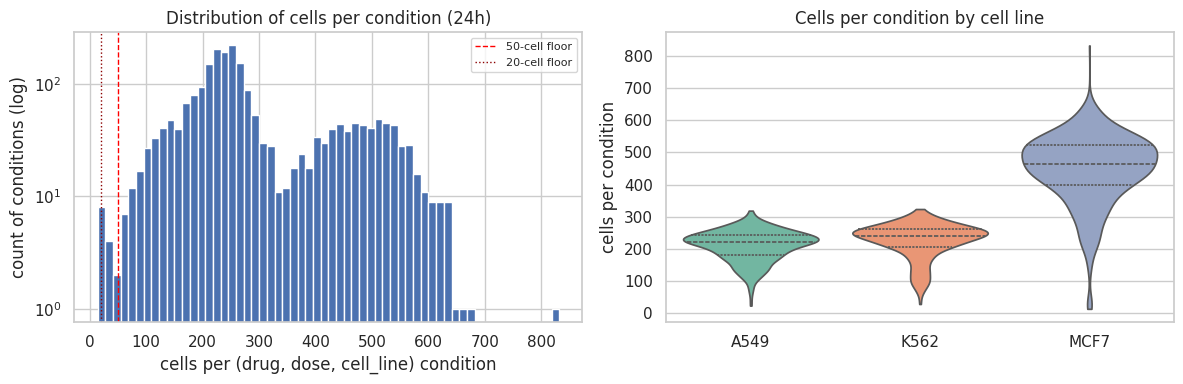

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Histogram, log y
ax = axes[0]
ax.hist(cond_counts["n_cells"], bins=60, color="#4c72b0", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("cells per (drug, dose, cell_line) condition")
ax.set_ylabel("count of conditions (log)")
ax.set_title("Distribution of cells per condition (24h)")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50-cell floor")
ax.axvline(20, color="darkred", linestyle=":", linewidth=1, label="20-cell floor")
ax.legend(fontsize=8)

# (b) Violin per cell line
ax = axes[1]
sns.violinplot(
    data=cond_counts, x="cell_line", y="n_cells",
    palette="Set2", inner="quartile", cut=0, ax=ax,
)
ax.set_title("Cells per condition by cell line")
ax.set_ylabel("cells per condition")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

## Plot 5 — Pathway_level_1 representation across drugs

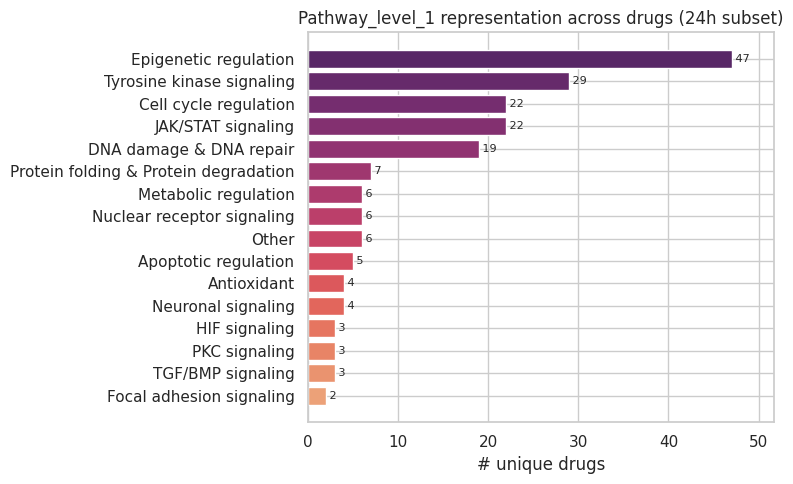

total distinct drugs across all pathways: 188


In [10]:
drugs_per_pathway = (drugs24.groupby("pathway_level_1")["perturbation"]
                     .nunique().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(drugs_per_pathway.index[::-1], drugs_per_pathway.values[::-1],
        color=sns.color_palette("flare", len(drugs_per_pathway)))
ax.set_xlabel("# unique drugs")
ax.set_title("Pathway_level_1 representation across drugs (24h subset)")
for i, v in enumerate(drugs_per_pathway.values[::-1]):
    ax.text(v, i, f" {v}", va="center", fontsize=8)
ax.set_xlim(0, drugs_per_pathway.max() * 1.10)
plt.tight_layout()
plt.show()
print(f"total distinct drugs across all pathways: {drugs_per_pathway.sum()}")

## UMAP — deferred to milestone 3 preprocessing

The scPerturb release ships with no precomputed embeddings (`obsm` is empty), so generating a UMAP requires HVG selection, normalization, PCA, neighbors graph, and UMAP layout on ~680k cells. That work belongs to milestone 3 preprocessing (where we also build the HVG list that becomes the regression head dimension) and is not redone here.

We will revisit a UMAP colored by cell line / pathway once the preprocessing pipeline produces a normalized HVG matrix.

## Aside — MAMMAL `cell_line_drug_response` input format (verified against source)

Resolving the open question from B.3 about how the task represents cells.

Prompt template (`mammal/examples/cell_line_drug_response/task.py:146–149`):

```
<@TOKENIZER-TYPE=SMILES><MASK>
<@TOKENIZER-TYPE=SMILES><MOLECULAR_ENTITY><MOLECULAR_ENTITY_SMALL_MOLECULE><SMILES_SEQUENCE>{drug_smiles}
<@TOKENIZER-TYPE=GENE><MOLECULAR_ENTITY><MOLECULAR_ENTITY_CELL_GENE_EXPRESSION_RANKED>[GENE1][GENE2]...[GENEn]
```

**Finding: the cell is represented purely by ranked gene expression — no cell-line ID token.**

- Drug side: SMILES string, BPE-tokenized.
- Cell side: a list of gene-symbol tokens `[BRCA1][TP53]...`, sorted descending by expression value (after pretraining-time binning into 10 bins, then sorted-by-bin then sorted-by-name within bin). Top ~1294 genes kept; lower-expressed genes truncated.
- `<MASK>` at the front is the readout position the scalar regression head reads from.

**Implications for CellCast (milestone 3):**
1. Cell-line conditioning is implicit in the expression profile we feed in. No vocabulary issue for MCF7/A549/K562 — they are not tokens. We just need each cell's pre-perturbation expression as the conditioning context.
2. For per-cell prediction, the natural choice is to feed that *cell's own* ranked expression. For per-cell-line prediction (matching the original task), feed a pseudobulk profile.
3. Adding dose is a real design question — there is no slot for it in this prompt. Options carried forward to milestone 3: discretize dose into a dose token, or use the `<@TOKENIZER-TYPE=SCALARS_LITERALS>` literal channel.
4. Widening the regression head from `[batch, 1]` to `[batch, num_HVGs]` is structurally trivial — same scalar-head pipeline, wider output.